<a href="https://colab.research.google.com/github/yeojeong735/2026-1-BDAP/blob/main/eda_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (31.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and direct

=== 1. 데이터 적재 확인 ===
총 로드된 데이터 수: 930개
Company Name                  object
Model Name                    object
Mobile Weight                float64
RAM                          float64
Front Camera                 float64
Back Camera                  float64
Processor                     object
Battery Capacity               int64
Screen Size                  float64
Launched Price (Pakistan)     object
Launched Price (India)        object
Launched Price (China)         int64
Launched Price (USA)         float64
Launched Price (Dubai)        object
Launched Year                  int64
dtype: object

=== 2. 주요 스펙 및 가격 기술 통계 ===
              RAM  Battery Capacity  Mobile Weight  Screen Size  \
count  928.000000        930.000000     930.000000   922.000000   
mean     7.784483       5026.163441     228.267097     7.082842   
std      3.183086       1355.548264     105.432503     1.539473   
min      1.000000       2000.000000     135.000000     5.000000   
25%      6.000000       4402

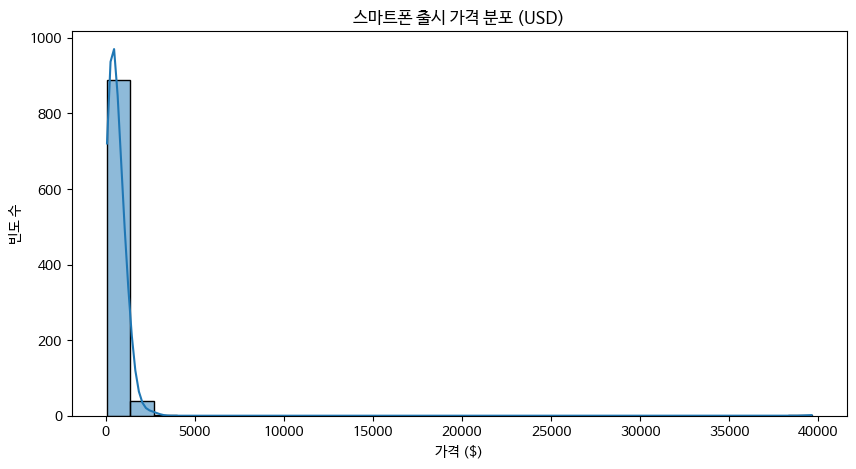

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumBarunGothic')

# 1. 정제된 데이터 적재
df = pd.read_csv("cleaned_mobiles_2025.csv")

print("=== 1. 데이터 적재 확인 ===")
print(f"총 로드된 데이터 수: {len(df)}개")
print(df.dtypes)

print("\n=== 2. 주요 스펙 및 가격 기술 통계 ===")
# 수치형 변수들의 요약 통계량 출력
print(df[['RAM', 'Battery Capacity', 'Mobile Weight', 'Screen Size', 'Launched Price (USA)']].describe())

print("\n=== 3. 제조사별 데이터 수 ===")
print(df['Company Name'].value_counts().head(10))

# 4. 간단한 시각화 확인 (가격 분포 확인용 히스토그램)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Launched Price (USA)', kde=True, bins=30)
plt.title("스마트폰 출시 가격 분포 (USD)")
plt.xlabel("가격 ($)")
plt.ylabel("빈도 수")
plt.show()

In [2]:
# 이상치 제거
df_clean = df[df['Launched Price (USA)'] <= 3000].copy()

print(f"이상치 제거 전 데이터 수: {len(df)}개")
print(f"이상치 제거 후 데이터 수: {len(df_clean)}개")
print(f"제거된 이상치 데이터 수: {len(df) - len(df_clean)}개")

# 필터링 후 다시 한번 통계량 확인
print(df_clean['Launched Price (USA)'].describe())

이상치 제거 전 데이터 수: 930개
이상치 제거 후 데이터 수: 929개
제거된 이상치 데이터 수: 1개
count     929.000000
mean      583.538924
std       421.189917
min        79.000000
25%       250.000000
50%       449.000000
75%       849.000000
max      2799.000000
Name: Launched Price (USA), dtype: float64


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


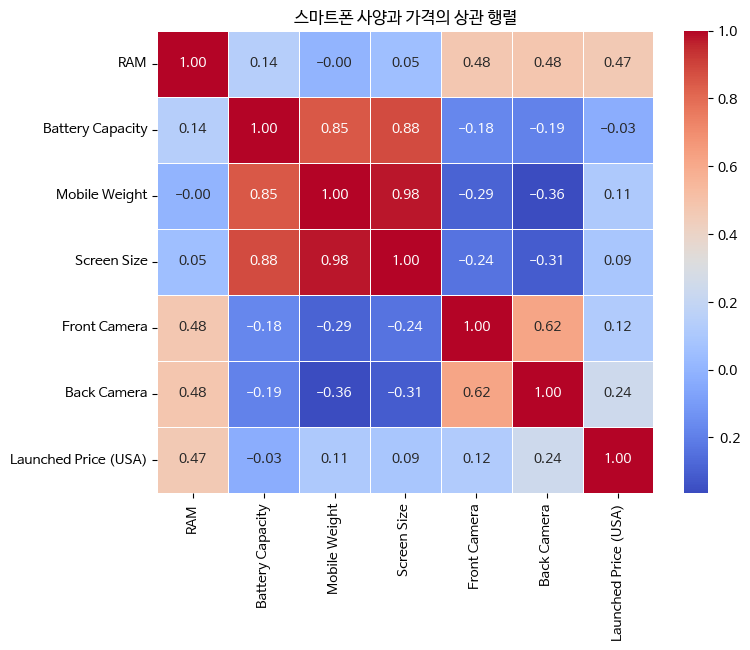

In [5]:
# 특성 간의 상관관계 시각화
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수들만 선택하여 상관계수 계산
numeric_cols = ['RAM', 'Battery Capacity', 'Mobile Weight', 'Screen Size', 'Front Camera', 'Back Camera', 'Launched Price (USA)']
corr_matrix = df_clean[numeric_cols].corr()

# 상관관계 히트맵 시각화 (Streamlit 탭 2에 들어갈 내용의 기반이 됩니다)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("스마트폰 사양과 가격의 상관 행렬")
plt.show()